In [14]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

In [12]:
X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400] 
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [8]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [13]:
log_reg.score(X_test, y_test)

0.7858942065491183

In [17]:
from sklearn.cluster import KMeans

In [18]:
k = 50
kmeans = KMeans(n_clusters=k)
X_digits_dist = kmeans.fit_transform(X_train)
representive_digit_idx = X_digits_dist.argmin(axis=0)
X_representative_digits = X_train[representive_digit_idx]

In [21]:
X_digits_dist

array([[50.61605024, 34.60633031, 25.30993071, ..., 39.82077475,
        50.67852109, 19.44507935],
       [33.26930434, 44.8373862 , 53.82309844, ..., 34.31700838,
        43.31065111, 54.55915005],
       [42.09658505, 49.73250683, 46.69205659, ..., 35.38138281,
        46.51142333, 48.3211302 ],
       ...,
       [30.79663647, 51.0609321 , 46.06316115, ..., 49.52617742,
        55.28166513, 45.9853191 ],
       [29.62091044, 49.68360058, 43.87397778, ..., 47.98253569,
        53.79881504, 43.87199718],
       [44.75548578, 40.22323262, 49.84457324, ..., 32.95155858,
        36.54705871, 47.77278845]], shape=(1400, 50))

In [22]:
representive_digit_idx

array([ 410, 1276, 1065,  326,  160,  768,  384,  162,  624,  310, 1321,
        360,  708, 1371,  738, 1161, 1168, 1312,  259,  991, 1012, 1046,
        612,  175,  925,  438,  514,  727,  200,  180, 1267,  815,  944,
        885,   40,  613,   51,  938,  877, 1352, 1164,  853,  579, 1383,
       1222,   58, 1309, 1295,  870,  406])

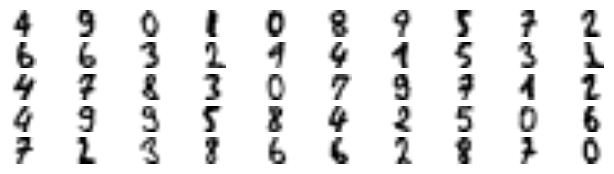

In [19]:

plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')


In [20]:
y_representative_digits = np.array([
    4,9,0,1,0,8,9,5,7,2,
    6,6,3,2,4,4,1,5,3,1,
    4,7,8,3,0,7,9,7,1,2,
    4,9,9,5,8,4,2,5,0,6,
    7,2,3,8,6,6,2,8,7,0
])

In [ ]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_)